In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

ROOT = Path.cwd().parent
df = pd.read_csv(ROOT / "data" / "processed" / "harga_pangan_manado_long.csv",
                parse_dates=["tanggal"])
varian = df[df["level"] == "varian"].copy()

print("Bentuk data  : ", df.shape)
print("Hanya varian : ", varian.shape)
varian.head()

Bentuk data  :  (13200, 5)
Hanya varian :  (8800, 5)


,komoditas,kategori,level,tanggal,harga
440,Bawang Merah Ukuran Sedang,Bawang Merah,varian,2025-01-01,47500.0
441,Bawang Merah Ukuran Sedang,Bawang Merah,varian,2025-01-02,46500.0
442,Bawang Merah Ukuran Sedang,Bawang Merah,varian,2025-01-03,46500.0
443,Bawang Merah Ukuran Sedang,Bawang Merah,varian,2025-01-06,46250.0
444,Bawang Merah Ukuran Sedang,Bawang Merah,varian,2025-01-07,45750.0


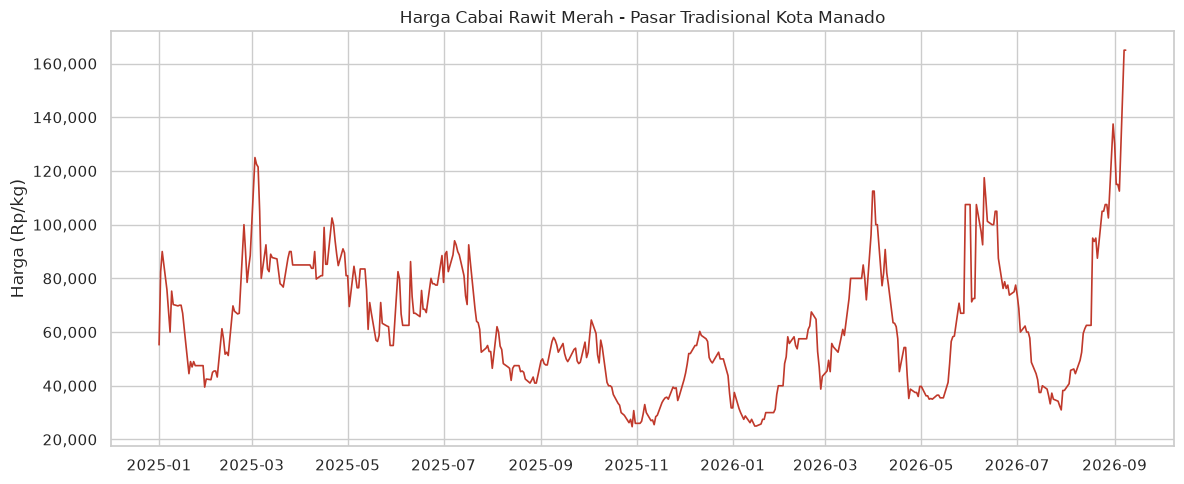

Terendah : Rp 24,750 pada 29 Oct 2025
Tertinggi: Rp 165,000 pada 07 Sep 2026


In [3]:
target = "Cabai Rawit Merah"
data = varian[varian["komoditas"] == target].sort_values("tanggal")

fig, ax = plt.subplots()
ax.plot(data["tanggal"], data["harga"], linewidth=1.2, color="#c0392b")
ax.set_title(f"Harga {target} - Pasar Tradisional Kota Manado")
ax.set_xlabel("")
ax.set_ylabel("Harga (Rp/kg)")
ax.yaxis.set_major_formatter(lambda x, p: f"{x:,.0f}")
plt.tight_layout()
plt.show()

print(f"Terendah : Rp {data['harga'].min():,.0f} pada {data.loc[data['harga'].idxmin(), 'tanggal']:%d %b %Y}")
print(f"Tertinggi: Rp {data['harga'].max():,.0f} pada {data.loc[data['harga'].idxmax(), 'tanggal']:%d %b %Y}")

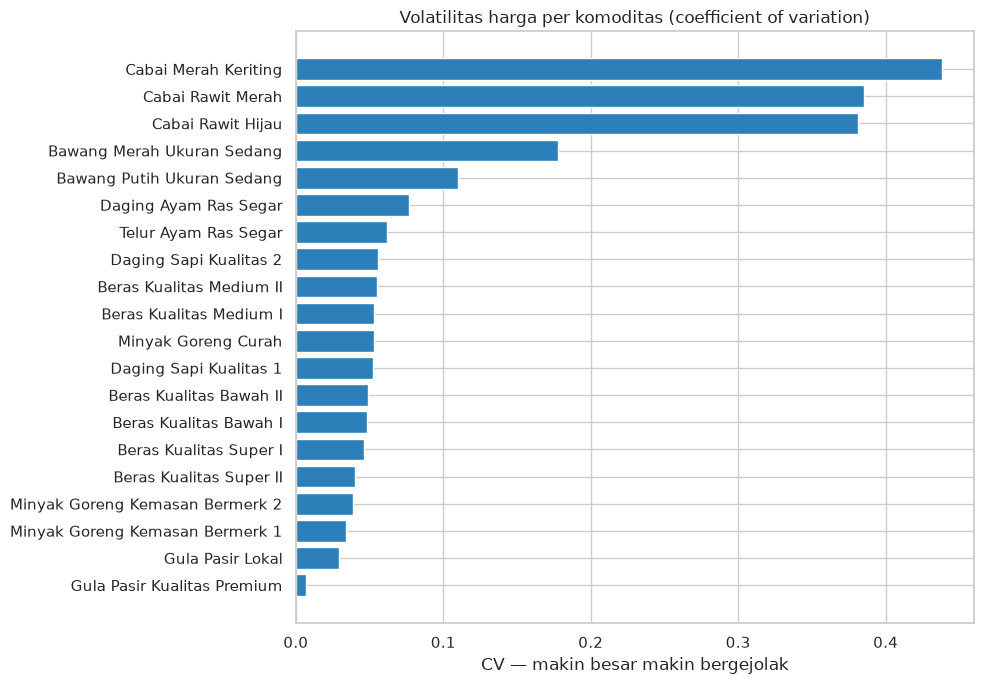

,rata,terendah,tertinggi,cv
komoditas,,,,
Cabai Merah Keriting,38083.636,11000.0,95000.0,0.438
Cabai Rawit Merah,61960.227,24750.0,165000.0,0.385
Cabai Rawit Hijau,56237.955,29000.0,137500.0,0.381
Bawang Merah Ukuran Sedang,47928.977,36250.0,101250.0,0.178
Bawang Putih Ukuran Sedang,40296.591,33750.0,67500.0,0.110
Daging Ayam Ras Segar,40272.727,36500.0,47750.0,0.077
Telur Ayam Ras Segar,30705.455,27400.0,34900.0,0.062
Daging Sapi Kualitas 2,132343.750,125000.0,150000.0,0.056
Beras Kualitas Medium II,15676.932,13900.0,16900.0,0.055


In [4]:
ringkas = (
    varian.groupby("komoditas")["harga"]
    .agg(rata="mean", terendah="min", tertinggi="max", stdev="std")
)
ringkas["rentang_relatif"] = (ringkas["tertinggi"] - ringkas["terendah"]) / ringkas["rata"]
ringkas["cv"] = ringkas["stdev"] / ringkas["rata"]
ringkas = ringkas.sort_values("cv", ascending=False).round(3)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(ringkas.index, ringkas["cv"], color="#2c7fb8")
ax.invert_yaxis()
ax.set_title("Volatilitas harga per komoditas (coefficient of variation)")
ax.set_xlabel("CV — makin besar makin bergejolak")
plt.tight_layout()
plt.show()

ringkas[["rata", "terendah", "tertinggi", "cv"]]